# The three-part trend rule on another market

On crypto perps a strict trend rule, a fitted line that is both steep and tight, traded beside the plain sign made more than either alone. It was found on data the lane had searched for weeks, so it cannot be believed from that data.

The fast way to test an idea without waiting for new weeks is to run it on a market it has never seen. This notebook runs the same two books, unchanged, on 66 US-listed ETFs across stocks, bonds, commodities and currencies from 2005 to 2026. Nothing in the rule was chosen on this data and the lane has never loaded it.

It is a registered test. The books, the universe, the cost and the pass, park and fail rules were written down and committed before this notebook was first run. It counts as one trial.

A pass here does not pass the crypto signal. It says the idea holds outside the market it was found in. A fail says the crypto result was probably fitted.

## Setup

Load adjusted daily closes for the 66 funds and build the same weekly panel the crypto books use. A fund trades in a week only if its median daily dollar volume over the prior 30 trading days was at least \$10M.

The books are the crypto books with the calendar changed. A week is 5 trading days, so the 28-day window becomes 20 trading days and the seven slices become five, one per weekday. The plain sign trades every liquid fund on the sign of its trailing 20-day return. The strict rule fits a line through the last 20 days of log price and trades a fund on the sign of the slope only where steepness is at least 2.0 and $R^2$ at least 0.8. The pair holds both at equal risk, each scaled by its own volatility over the prior 52 weeks.

Cost is 7.5 bps each way on every change of weight. There is no funding. The cost of borrowing a fund to short it is not modelled.

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from book import Book, sharpe
import etf, gate, panel, rule

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.grid': True, 'grid.alpha': 0.25, 'lines.linewidth': 2})
BLUE, ORANGE, GREY = '#2a78d6', '#eb6834', '#8a8a86'

DAYS, PER_WEEK = 20, 5
WEEKS = ['W-MON', 'W-TUE', 'W-WED', 'W-THU', 'W-FRI']

bars = etf.daily_bars('2005-01-01', '2026-09-01', log=lambda m: None)
close = bars.pivot(index='day', columns='symbol', values='close')
volume = bars.pivot(index='day', columns='symbol', values='volume')
daily = panel.daily_returns(close, volume > 0)
held = panel.held_returns(close, volume > 0).fillna(0.0)
books = {week: Book(panel.build(bars, None, week=week)) for week in WEEKS}
fri = books['W-FRI']
ln = rule.lines(daily, DAYS)

def run(weights, **cost):
    """Weekly net of the five-slice book whose slice weights come from weights(b, week)."""
    return rule.sliced(books, weights, held, **cost)

plain_w = lambda b, week: rule.plain(b, ln, week, DAYS, PER_WEEK)
strict_w = lambda b, week: rule.strict(b, ln, week, DAYS, PER_WEEK)
print(f'funds {bars.symbol.nunique()}   days {len(close)}   {close.index.min().date()} .. {close.index.max().date()}   weeks {len(fri.W)}')

funds 66   days 5449   2005-01-03 .. 2026-08-31   weeks 1131


## Checking the data

Before any book is run, look at what was loaded. How many funds there are and when each starts, how many clear the liquidity floor each year, and whether the prices hold anything a cleaning rule should catch.

In [2]:
liquid = (fri.LIQ >= 1e7) & fri.VOL.notna()
print('funds by first year', bars.groupby('symbol').day.min().dt.year.value_counts().sort_index().to_dict())
print('funds over $10M a day, mean per week by year', liquid.sum(axis=1).groupby(liquid.index.year).mean().round(0).astype(int).to_dict())
idle = (volume <= 0) & close.notna()
print('days with a price and no volume', idle.sum()[idle.sum() > 0].sort_values(ascending=False).to_dict())
jump = np.log(close).diff().abs() > 0.3
print('daily moves over 30%, all days', int(jump.sum().sum()), '  on traded days', int((jump & (volume > 0) & (volume.shift(1) > 0)).sum().sum()))

funds by first year {2005: 45, 2006: 9, 2007: 9, 2010: 1, 2011: 1, 2012: 1}
funds over $10M a day, mean per week by year {2005: 16, 2006: 31, 2007: 38, 2008: 47, 2009: 49, 2010: 52, 2011: 54, 2012: 53, 2013: 55, 2014: 53, 2015: 55, 2016: 57, 2017: 56, 2018: 56, 2019: 50, 2020: 55, 2021: 56, 2022: 55, 2023: 51, 2024: 51, 2025: 47, 2026: 58}
days with a price and no volume {'CPER': 329, 'INDA': 25, 'FXB': 6, 'FXA': 2, 'EMB': 1, 'UUP': 1}
daily moves over 30%, all days 5   on traded days 1


All 66 funds loaded. 45 have prices from the start of 2005 and the rest list by 2012. From 2008 about 50 to 58 funds clear the \$10M floor each week, so the cross-section is a third the size of the liquid crypto universe.

Days with a price and no volume sit almost entirely in one small copper fund, 329 of 364. Of the five daily moves over 30%, four are bad prints on those idle days, which the cleaning rule drops because nothing traded. The one on a traded day is silver falling 29% on 30 January 2026, on record volume.

## Checking the backtest before believing it

Three checks, the same ones every sweep in the lane ran first. Random signals should lose roughly the cost of trading. A signal one week older should do worse, never better, or the backtest is seeing the future. And zero, one and two times cost should give three different answers, or cost is not wired in.

In [3]:
rng = np.random.default_rng(0)
def random_w(b, week):
    sig = pd.DataFrame(rng.choice([-1.0, 1.0], size=b.W.shape), index=b.W.index, columns=b.W.columns).where(b.VOL.notna())
    return b.sized(sig.shift(1))
rand = [sharpe(run(random_w)) for _ in range(20)]
print(f'random signs, 20 runs   net Sharpe mean {np.mean(rand):+.2f}   range {min(rand):+.2f} .. {max(rand):+.2f}')
older = lambda b, week: rule.plain(b, ln, week, DAYS, PER_WEEK).shift(1)
print(f'plain sign   net Sharpe {sharpe(run(plain_w)):+.2f}   signal one week older {sharpe(run(older)):+.2f}')
print('plain sign at 0x 1x 2x cost', [round(sharpe(run(plain_w, cost_mult=m)), 2) for m in (0.0, 1.0, 2.0)])

random signs, 20 runs   net Sharpe mean -4.70   range -5.13 .. -4.23


plain sign   net Sharpe -0.17   signal one week older -0.20


plain sign at 0x 1x 2x cost [np.float64(0.13), np.float64(-0.17), np.float64(-0.47)]


The checks pass, and the first one says something about this market. Random signs lose 4.70 in Sharpe, far more than on crypto. The loss is the same size in money, a book that flips at random turns over about once a week and pays 7.5 bps on it, close to 4% a year. But these funds move a fifth as much as coins, so the same cost is a much larger share of what the book can earn.

A signal one week older makes $-0.20$ against $-0.17$, so the backtest is not seeing the future. The three cost levels give 0.13, $-0.17$ and $-0.47$. Cost is wired in, and here it decides the sign of the result.

## The registered books

Run the plain sign, the strict rule and the pair as registered. For each, the Sharpe, the return, the worst week, the share of losing weeks and the deepest drawdown in summed weekly returns, then every year, and how many funds the strict rule holds.

1089 weeks from 2005-10-30, each book scaled to the plain sign's risk

             Sharpe  return % a year  worst week %  weeks losing %  deepest drawdown  correlation with plain
plain sign    -0.17            -1.03         -5.90           50.05             -0.43                    1.00
strict rule   -0.12            -0.75         -8.75           52.25             -0.51                    0.48
pair          -0.16            -0.98         -5.84           52.07             -0.45                    0.78

Sharpe by year
day          2005  2006  2007  2008  2009  2010  2011  2012  2013  2014  2015  2016  2017  2018  2019  2020  2021  2022  2023  2024  2025  2026
plain sign   1.44  0.49 -0.45  1.20 -0.10 -0.57 -1.24 -0.20 -0.51 -0.88 -0.77 -0.48 -1.41 -0.14 -0.91  0.18 -0.71  0.14 -0.33 -1.32 -1.18 -0.70
strict rule -0.31  0.83 -0.11  1.91 -1.16 -0.57 -1.16  0.99 -0.57  0.54  0.28 -1.34 -1.50  0.47 -0.21 -1.02 -0.19 -1.14  0.68 -1.77  0.23  0.88
pair         0.41  0.63 -0.34  1.91 -0.79 -0.


funds held by the strict rule, per slice   median 2   weeks under 3 funds 68%   weeks with none 10%


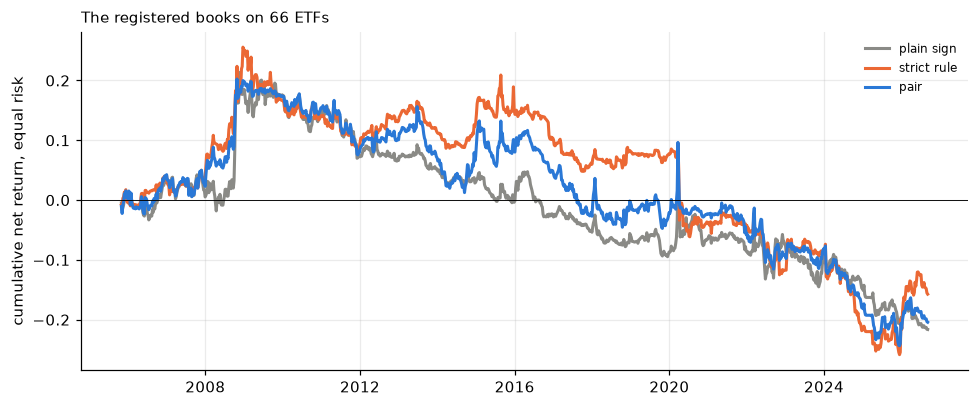

In [4]:
p, s = run(plain_w), run(strict_w)
first = max(p.index[0], s.index[0])
p, s = p.loc[first:], s.loc[first:]
both = rule.pair(p, s)
series = {'plain sign': p.reindex(both.index), 'strict rule': s.reindex(both.index), 'pair': both}

def drawdown(x):
    c = x.cumsum()
    return (c - c.cummax()).min()

unit = {k: v / v.std() * series['plain sign'].std() for k, v in series.items()}
stats = pd.DataFrame({k: {'Sharpe': sharpe(v), 'return % a year': unit[k].mean() * 5200, 'worst week %': unit[k].min() * 100,
                          'weeks losing %': (v < 0).mean() * 100, 'deepest drawdown': drawdown(unit[k]),
                          'correlation with plain': v.corr(series['plain sign'])} for k, v in series.items()}).T
print(f'{len(both)} weeks from {both.index[0].date()}, each book scaled to the plain sign\'s risk\n')
print(stats.round(2).to_string())
print('\nSharpe by year')
print(pd.DataFrame({k: v.groupby(v.index.year).apply(sharpe) for k, v in series.items()}).T.round(2).to_string())
count = pd.concat([strict_w(b, week).fillna(0.0).ne(0).sum(axis=1).reindex(fri.W.index, method='nearest') for week, b in books.items()], axis=1).mean(axis=1).loc[first:]
print(f'\nfunds held by the strict rule, per slice   median {count.median():.0f}   weeks under 3 funds {(count < 3).mean():.0%}   weeks with none {(count == 0).mean():.0%}')

fig, ax = plt.subplots(figsize=(9, 3.8))
for k, color in [('plain sign', GREY), ('strict rule', ORANGE), ('pair', BLUE)]:
    ax.plot(unit[k].cumsum(), color=color, label=k)
ax.axhline(0, color='k', lw=0.6); ax.set_ylabel('cumulative net return, equal risk')
ax.set_title('The registered books on 66 ETFs', loc='left', fontsize=10); ax.legend(frameon=False, fontsize=8)
plt.tight_layout(); plt.show()

Nothing earns. Over 1,089 weeks the plain sign makes $-0.17$, the strict rule $-0.12$ and the pair $-0.16$.

The plain sign is positive in 5 of 22 years, 2005, 2006, 2008, 2020 and 2022, and loses from 2009 to 2019 without a break. Four-week trend on these funds is not a paying signal net of this cost, so the test starts from a base that does not work.

The strict rule is the same kind of book it was on crypto. It holds a median of 2 funds, under 3 in 68% of weeks and none in 10%, and its returns correlate 0.48 with the plain sign's. It is positive in 9 of 22 years, with its best in 2008 at 1.91, and it does not carry the pair. The pair lands between its two halves.

## Against the gate

The pair is the registered claim, scored as one trial. Its probability of being real, whether it survives dropping any one year, its bootstrap floor and twice the cost. Then the two things the claim itself asserts, that the strict rule earns on its own and that the pair beats the plain sign.

In [5]:
x = series['pair']
prob, bar = gate.significance(x, 1.0)
s2, keep = gate.year_stability(x)
boot = gate.bootstrap(x)
p2, s2x = run(plain_w, cost_mult=2.0), run(strict_w, cost_mult=2.0)
twice = sharpe(rule.pair(p2.loc[first:], s2x.loc[first:]))
long_basket = sharpe(run(lambda b, week: b.basket()).reindex(x.index))
edge = (unit['pair'] - unit['plain sign'])
checks = {'S1': ('pass' if prob >= gate.CONFIDENCE else 'park' if prob >= gate.PARK else 'fail', f'probability {prob:.2f}, Sharpe {sharpe(x):.2f}, {len(x)} weeks, luck bar {bar:.2f}'),
          'S2': ('pass' if s2 else 'fail', f'worst year removed keeps {keep:.0%} of the Sharpe'),
          'S6': ('pass' if sharpe(x) > max(long_basket, -long_basket) else 'fail', f'long basket {long_basket:.2f}, short basket {-long_basket:.2f}'),
          'C4': ('pass' if twice > 0 else 'fail', f'twice cost {twice:.2f}'),
          'V1': ('pass' if boot['sharpe 5%'] > 0 else 'fail', f"5th percentile {boot['sharpe 5%']:.2f}, ends above zero {boot['ends above zero']:.0%}, median drawdown {boot['drawdown 50%']:.2f}")}
for k, (status, note) in checks.items():
    print(f'{k}  {status:5} {note}')
failed = [k for k, (st, _) in checks.items() if st == 'fail' and k != 'S1']
print('\nstamp on the ETF data', gate.stamp(failed, prob, sharpe(x), 1.0, open_items=['D3', 'C2']))
print(f"\nthe claim   strict rule Sharpe {sharpe(series['strict rule']):.2f}   pair {sharpe(x):.2f} against plain sign {sharpe(series['plain sign']):.2f}   "
      f"pair minus plain {edge.mean() * 100:+.3f}% a week, t {edge.mean() / edge.std() * np.sqrt(len(edge)):.2f}")
print('registered fail rules', {'probability below 0.5': bool(prob < gate.PARK), 'strict rule negative': bool(sharpe(series['strict rule']) < 0),
                                'pair below the plain sign': bool(sharpe(x) < sharpe(series['plain sign']))})

S1  fail  probability 0.24, Sharpe -0.16, 1089 weeks, luck bar 0.00
S2  fail  worst year removed keeps nan% of the Sharpe
S6  fail  long basket 0.20, short basket -0.20
C4  fail  twice cost -0.55
V1  fail  5th percentile -0.48, ends above zero 21%, median drawdown -45.96

stamp on the ETF data gate fail S1 S2 S6 C4 V1, open D3 C2

the claim   strict rule Sharpe -0.12   pair -0.16 against plain sign -0.17   pair minus plain +0.001% a week, t 0.06
registered fail rules {'probability below 0.5': True, 'strict rule negative': True, 'pair below the plain sign': False}


The registered test fails on Data C. The pair is real with probability 0.24 on one trial, under the 0.5 fail line, and fails every other check that was run, year stability, the baskets, twice cost and the bootstrap, where 21% of resampled paths end above zero.

Two of the three registered fail rules fire. The probability is below 0.5 and the strict rule is negative. The third does not, the pair sits a hair above the plain sign, $-0.16$ against $-0.17$, but the gap is 0.001% a week at t 0.06, which is nothing.

Stamp, gate fail S1 S2 S6 C4 V1, open D3 C2.

## After the registered run, the cost

This section is not part of the registered test and cannot change its result. It asks one question the result raises. The cost was set at 7.5 bps, the crypto figure, on funds that move a fifth as much and trade for a fraction of that. Did the cost alone sink the books, or is there nothing underneath it. Rerun the three books with no cost and at 1.5 bps, and split the no-cost run into three spans.

In [6]:
rows = {}
for mult, label in [(0.0, 'no cost'), (0.2, '1.5 bps'), (1.0, '7.5 bps, registered')]:
    a, b_ = run(plain_w, cost_mult=mult).loc[first:], run(strict_w, cost_mult=mult).loc[first:]
    c = rule.pair(a, b_)
    rows[label] = {'plain sign': sharpe(a.reindex(c.index)), 'strict rule': sharpe(b_.reindex(c.index)), 'pair': sharpe(c), 'pair probability': gate.significance(c, 1.0)[0]}
    if mult == 0.0:
        free = {'plain sign': a.reindex(c.index), 'strict rule': b_.reindex(c.index), 'pair': c}
print(pd.DataFrame(rows).T.round(2).to_string())
print('\nno cost, by span')
spans = {'2005 to 2012': (2005, 2012), '2013 to 2019': (2013, 2019), '2020 to 2026': (2020, 2026)}
print(pd.DataFrame({name: {k: sharpe(v[(v.index.year >= lo) & (v.index.year <= hi)]) for k, v in free.items()} for name, (lo, hi) in spans.items()}).T.round(2).to_string())
for label, w in [('plain sign', plain_w), ('strict rule', strict_w)]:
    r = fri.run(w(fri, 'W-FRI'))
    print(f'{label}, Friday slice   turnover {r.turnover.mean():.2f} a week   cost {-r.cost.mean() * 5200:.1f}% a year   volatility {r.net.std() * np.sqrt(52) * 100:.1f}% a year')

                     plain sign  strict rule  pair  pair probability
no cost                    0.13         0.16  0.23              0.86
1.5 bps                    0.07         0.10  0.16              0.76
7.5 bps, registered       -0.17        -0.12 -0.16              0.24

no cost, by span
              plain sign  strict rule  pair
2005 to 2012        0.35         0.54  0.56
2013 to 2019       -0.07         0.23  0.29
2020 to 2026       -0.02        -0.23 -0.10
plain sign, Friday slice   turnover 0.49 a week   cost 1.9% a year   volatility 6.3% a year
strict rule, Friday slice   turnover 1.05 a week   cost 4.1% a year   volatility 16.7% a year


The cost was too heavy for this market, and removing it does not rescue the result. A slice of the plain sign pays 1.9% a year in cost on a book that moves 6.3% a year, and a slice of the strict rule pays 4.1% on 16.7%. On crypto the same 7.5 bps sat against books moving several times as much.

With no cost at all the plain sign makes 0.13, the strict rule 0.16 and the pair 0.23. At 1.5 bps, nearer what these funds cost to trade, 0.07, 0.10 and 0.16. The pair is above the plain sign at every cost level, the direction the crypto result pointed, but a Sharpe of 0.2 before cost over 21 years is not an edge anyone could trade, and its probability of being real with no cost is 0.86, short of a pass even then.

What there is sits in the early years. With no cost the pair makes 0.56 from 2005 to 2012, 0.29 from 2013 to 2019 and $-0.10$ from 2020. The strict rule fades the same way and is negative in the last span.

## Verdict

The registered test fails on the ETF data. The pair makes $-0.16$ over 1,089 weeks, real with probability 0.24 on one trial, and two of the three registered fail rules fire, the probability under 0.5 and the strict rule negative at $-0.12$. Gate fail S1 S2 S6 C4 V1.

The idea did not carry to another market. Four-week trend does not pay on these funds, $-0.17$ for the plain sign, so the strict rule had no working base to improve on, and it did not earn on its own either.

The registered cost of 7.5 bps was heavy for funds that move a fifth as much as coins, and the failure does not rest on it. With no cost the pair makes 0.23, above the plain sign's 0.13 and far below anything tradable, and all of it comes from before 2013.

So the crypto pair has no support from outside crypto. It stays an exploratory lead found on searched data. What remains for it is the forward run on perps, and a reason it would hold in crypto and not elsewhere, which this test does not supply.